# Surface Engine Demo

This notebook demonstrates the core components of Valorem's Surface Engine (Phase 3, Milestones 7-10):

1. **IV Solver** - Black-Scholes implied volatility inversion using Newton-Raphson
2. **Greeks Calculator** - Analytical Greeks (delta, gamma, vega, theta)
3. **Bucket Assignment** - Delta-based option classification
4. **Quality Filters** - Bitfield-encoded quality flags
5. **Surface Builder** - Full pipeline orchestration

In [ ]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Surface Engine components
from src.surface.iv.black_scholes import BlackScholesIVSolver
from src.surface.greeks.analytical import AnalyticalGreeks
from src.surface.buckets.assign import DeltaBucketAssigner
from src.surface.quality.filters import QualityFilter, QualityConfig
from src.config.constants import SurfaceConstants

pd.set_option('display.float_format', '{:.4f}'.format)
print("Surface Engine components loaded successfully!")

## 1. IV Solver Demo

The `BlackScholesIVSolver` inverts option prices to implied volatility using Newton-Raphson iteration.

In [2]:
# Initialize solver
iv_solver = BlackScholesIVSolver(max_iters=100, tolerance=1e-6)

# Sample option chain parameters
S = 480.0  # Underlying price (SPY)
r = 0.045  # Risk-free rate (4.5%)
q = 0.0    # Dividend yield
T = 30/365 # 30 days to expiry

# Create a range of strikes
strikes = np.arange(450, 510, 5, dtype=float)

# Known IVs (to generate synthetic prices)
# Using a simple skew: higher IV for OTM puts, lower for OTM calls
moneyness = strikes / S
true_ivs = 0.18 + 0.15 * (1 - moneyness)  # Simple skew model

print(f"Underlying: ${S:.2f}")
print(f"Risk-free rate: {r*100:.2f}%")
print(f"Time to expiry: {T*365:.0f} days")
print(f"\nStrikes: {strikes}")
print(f"True IVs: {true_ivs.round(4)}")

Underlying: $480.00
Risk-free rate: 4.50%
Time to expiry: 30 days

Strikes: [450. 455. 460. 465. 470. 475. 480. 485. 490. 495. 500. 505.]
True IVs: [0.1894 0.1878 0.1862 0.1847 0.1831 0.1816 0.18   0.1784 0.1769 0.1753
 0.1737 0.1722]


In [3]:
# Generate synthetic call prices using Black-Scholes
from scipy.stats import norm

def bs_call_price(S, K, T, r, q, sigma):
    """Black-Scholes call price."""
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

# Generate call prices
call_prices = bs_call_price(S, strikes, T, r, q, true_ivs)
print("Synthetic call prices:")
for k, p, iv in zip(strikes, call_prices, true_ivs):
    print(f"  K={k:.0f}: Price=${p:.2f}, True IV={iv*100:.1f}%")

Synthetic call prices:
  K=450: Price=$32.92, True IV=18.9%
  K=455: Price=$28.54, True IV=18.8%
  K=460: Price=$24.37, True IV=18.6%
  K=465: Price=$20.47, True IV=18.5%
  K=470: Price=$16.88, True IV=18.3%
  K=475: Price=$13.64, True IV=18.2%
  K=480: Price=$10.77, True IV=18.0%
  K=485: Price=$8.31, True IV=17.8%
  K=490: Price=$6.24, True IV=17.7%
  K=495: Price=$4.55, True IV=17.5%
  K=500: Price=$3.22, True IV=17.4%
  K=505: Price=$2.21, True IV=17.2%


In [4]:
# Now invert to recover IVs
recovered_ivs = iv_solver.solve_iv_vectorized(
    prices=pd.Series(call_prices),
    S=pd.Series([S] * len(strikes)),
    K=pd.Series(strikes),
    T=pd.Series([T] * len(strikes)),
    r=pd.Series([r] * len(strikes)),
    q=q,
    right=pd.Series(['C'] * len(strikes))
)

# Compare
comparison = pd.DataFrame({
    'Strike': strikes,
    'Price': call_prices,
    'True IV': true_ivs,
    'Recovered IV': recovered_ivs.values,
    'Error (bps)': (recovered_ivs.values - true_ivs) * 10000
})
print("IV Solver Accuracy:")
print(comparison.to_string(index=False))
print(f"\nMax error: {comparison['Error (bps)'].abs().max():.2f} bps")

IV Solver Accuracy:
  Strike   Price  True IV  Recovered IV  Error (bps)
450.0000 32.9170   0.1894        0.1894      -0.0000
455.0000 28.5360   0.1878        0.1878      -0.0000
460.0000 24.3719   0.1862        0.1862      -0.0000
465.0000 20.4716   0.1847        0.1847      -0.0000
470.0000 16.8802   0.1831        0.1831       0.0000
475.0000 13.6375   0.1816        0.1816       0.0000
480.0000 10.7739   0.1800        0.1800      -0.0000
485.0000  8.3063   0.1784        0.1784      -0.0000
490.0000  6.2366   0.1769        0.1769      -0.0000
495.0000  4.5509   0.1753        0.1753      -0.0000
500.0000  3.2206   0.1737        0.1737      -0.0000
505.0000  2.2058   0.1722           NaN          NaN

Max error: 0.00 bps


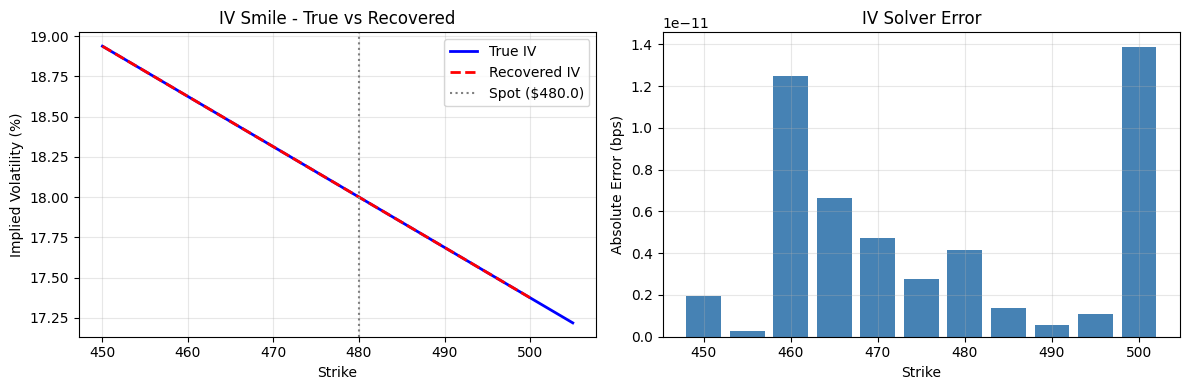

In [5]:
# Visualize the IV smile
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(strikes, true_ivs * 100, 'b-', label='True IV', linewidth=2)
ax1.plot(strikes, recovered_ivs * 100, 'r--', label='Recovered IV', linewidth=2)
ax1.axvline(S, color='gray', linestyle=':', label=f'Spot (${S})')
ax1.set_xlabel('Strike')
ax1.set_ylabel('Implied Volatility (%)')
ax1.set_title('IV Smile - True vs Recovered')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.bar(strikes, comparison['Error (bps)'].abs(), width=4, color='steelblue')
ax2.set_xlabel('Strike')
ax2.set_ylabel('Absolute Error (bps)')
ax2.set_title('IV Solver Error')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Greeks Calculator Demo

The `AnalyticalGreeks` class computes option sensitivities using closed-form Black-Scholes formulas.

In [6]:
# Initialize Greeks calculator
greeks_calc = AnalyticalGreeks()

# Compute Greeks for our option chain
greeks_df = greeks_calc.compute_greeks_vectorized(
    S=pd.Series([S] * len(strikes)),
    K=pd.Series(strikes),
    T=pd.Series([T] * len(strikes)),
    r=r,
    q=q,
    sigma=pd.Series(recovered_ivs.values),
    right=pd.Series(['C'] * len(strikes))
)

# Display results
greeks_df['Strike'] = strikes
greeks_df['IV'] = recovered_ivs.values
greeks_df = greeks_df[['Strike', 'IV', 'delta', 'gamma', 'vega', 'theta']]

print("Call Option Greeks:")
print(greeks_df.to_string(index=False))

Call Option Greeks:
  Strike     IV  delta  gamma    vega    theta
450.0000 0.1894 0.9004 0.0067 24.0750 -45.7031
455.0000 0.1878 0.8619 0.0085 30.3418 -51.9997
460.0000 0.1862 0.8141 0.0104 36.8463 -58.2350
465.0000 0.1847 0.7568 0.0123 43.0916 -63.8390
470.0000 0.1831 0.6907 0.0140 48.5036 -68.1921
475.0000 0.1816 0.6172 0.0153 52.5109 -70.7173
480.0000 0.1800 0.5388 0.0160 54.6389 -70.9834
485.0000 0.1784 0.4583 0.0162 54.5991 -68.7928
490.0000 0.1769 0.3789 0.0156 52.3506 -64.2326
495.0000 0.1753 0.3038 0.0145 48.1174 -57.6736
500.0000 0.1737 0.2357 0.0129 42.3531 -49.7116
505.0000    NaN    NaN    NaN     NaN      NaN


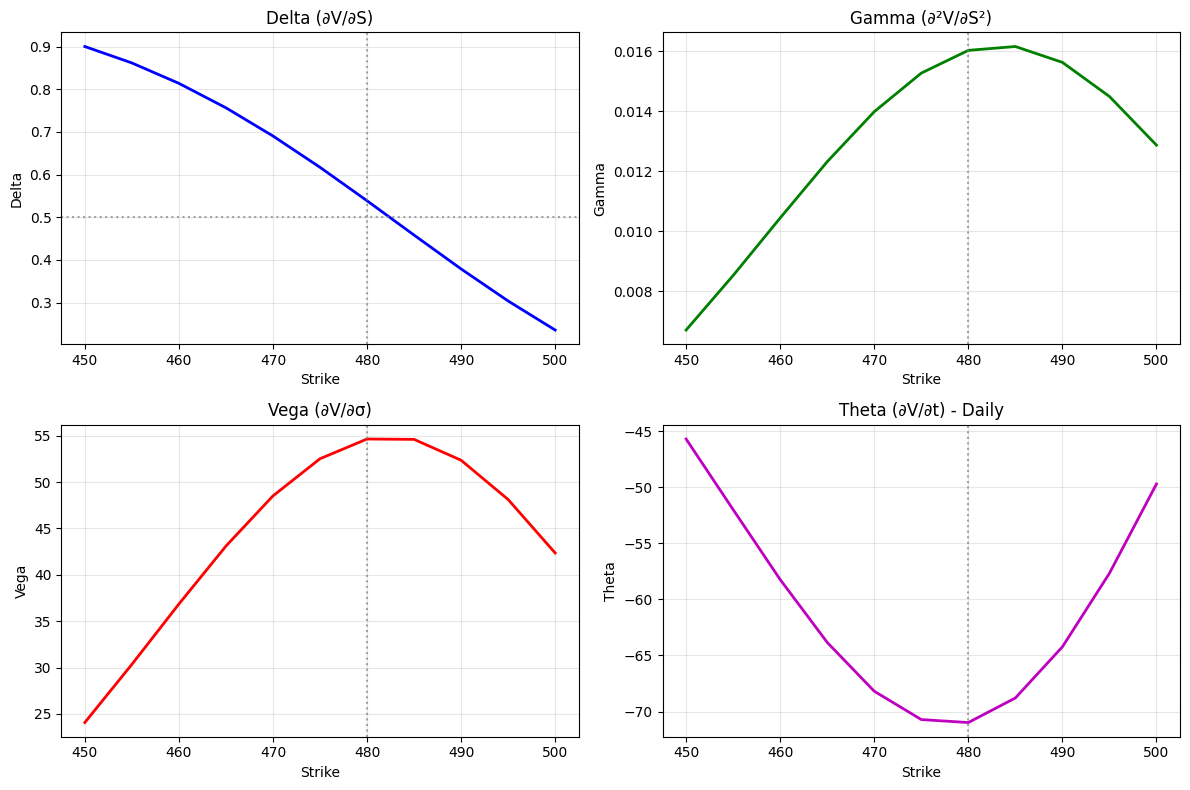

In [7]:
# Visualize Greeks
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Delta
axes[0, 0].plot(strikes, greeks_df['delta'], 'b-', linewidth=2)
axes[0, 0].axhline(0.5, color='gray', linestyle=':', alpha=0.7)
axes[0, 0].axvline(S, color='gray', linestyle=':', alpha=0.7)
axes[0, 0].set_xlabel('Strike')
axes[0, 0].set_ylabel('Delta')
axes[0, 0].set_title('Delta (∂V/∂S)')
axes[0, 0].grid(True, alpha=0.3)

# Gamma
axes[0, 1].plot(strikes, greeks_df['gamma'], 'g-', linewidth=2)
axes[0, 1].axvline(S, color='gray', linestyle=':', alpha=0.7)
axes[0, 1].set_xlabel('Strike')
axes[0, 1].set_ylabel('Gamma')
axes[0, 1].set_title('Gamma (∂²V/∂S²)')
axes[0, 1].grid(True, alpha=0.3)

# Vega
axes[1, 0].plot(strikes, greeks_df['vega'], 'r-', linewidth=2)
axes[1, 0].axvline(S, color='gray', linestyle=':', alpha=0.7)
axes[1, 0].set_xlabel('Strike')
axes[1, 0].set_ylabel('Vega')
axes[1, 0].set_title('Vega (∂V/∂σ)')
axes[1, 0].grid(True, alpha=0.3)

# Theta
axes[1, 1].plot(strikes, greeks_df['theta'], 'm-', linewidth=2)
axes[1, 1].axvline(S, color='gray', linestyle=':', alpha=0.7)
axes[1, 1].set_xlabel('Strike')
axes[1, 1].set_ylabel('Theta')
axes[1, 1].set_title('Theta (∂V/∂t) - Daily')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Bucket Assignment Demo

The `DeltaBucketAssigner` classifies options into standardized delta buckets for surface construction.

In [8]:
# Define bucket configuration (standard 7-bucket layout)
bucket_config = {
    # ATM uses |delta| matching (4 elements: put_min, put_max, call_min, call_max)
    "ATM": [-0.55, -0.45, 0.45, 0.55],
    # OTM Puts (negative delta)
    "P40": [-0.45, -0.35],
    "P25": [-0.35, -0.20],
    "P10": [-0.20, 0.0],
    # OTM Calls (positive delta) 
    "C10": [0.0, 0.20],
    "C25": [0.20, 0.35],
    "C40": [0.35, 0.45],
}

# Initialize assigner
bucket_assigner = DeltaBucketAssigner(bucket_config)

print("Bucket Configuration:")
for name in bucket_assigner.get_bucket_names():
    bounds = bucket_assigner.get_bucket_bounds(name)
    if name == "ATM":
        print(f"  {name}: |delta| in [{bounds[0]:.2f}, {bounds[1]:.2f}]")
    else:
        print(f"  {name}: delta in [{bounds[0]:.2f}, {bounds[1]:.2f}]")

Bucket Configuration:
  ATM: |delta| in [0.45, 0.55]
  P40: delta in [-0.45, -0.35]
  P25: delta in [-0.35, -0.20]
  P10: delta in [-0.20, 0.00]
  C10: delta in [0.00, 0.20]
  C25: delta in [0.20, 0.35]
  C40: delta in [0.35, 0.45]


In [9]:
# Create a full option chain (calls and puts)
# Calls
call_deltas = greeks_df['delta'].values

# Puts (delta = call_delta - 1)
put_deltas = call_deltas - 1

# Combine into a DataFrame
all_options = pd.DataFrame({
    'Strike': list(strikes) + list(strikes),
    'Right': ['C'] * len(strikes) + ['P'] * len(strikes),
    'Delta': list(call_deltas) + list(put_deltas),
})

# Assign buckets
all_options['Bucket'] = bucket_assigner.assign(pd.Series(all_options['Delta']))

# Display
print("Option Bucket Assignments:")
print(all_options.sort_values(['Right', 'Strike']).to_string(index=False))

Option Bucket Assignments:
  Strike Right   Delta Bucket
450.0000     C  0.9004   None
455.0000     C  0.8619   None
460.0000     C  0.8141   None
465.0000     C  0.7568   None
470.0000     C  0.6907   None
475.0000     C  0.6172   None
480.0000     C  0.5388    ATM
485.0000     C  0.4583    ATM
490.0000     C  0.3789    C40
495.0000     C  0.3038    C25
500.0000     C  0.2357    C25
505.0000     C     NaN   None
450.0000     P -0.0996    P10
455.0000     P -0.1381    P10
460.0000     P -0.1859    P10
465.0000     P -0.2432    P25
470.0000     P -0.3093    P25
475.0000     P -0.3828    P40
480.0000     P -0.4612    ATM
485.0000     P -0.5417    ATM
490.0000     P -0.6211   None
495.0000     P -0.6962   None
500.0000     P -0.7643   None
505.0000     P     NaN   None


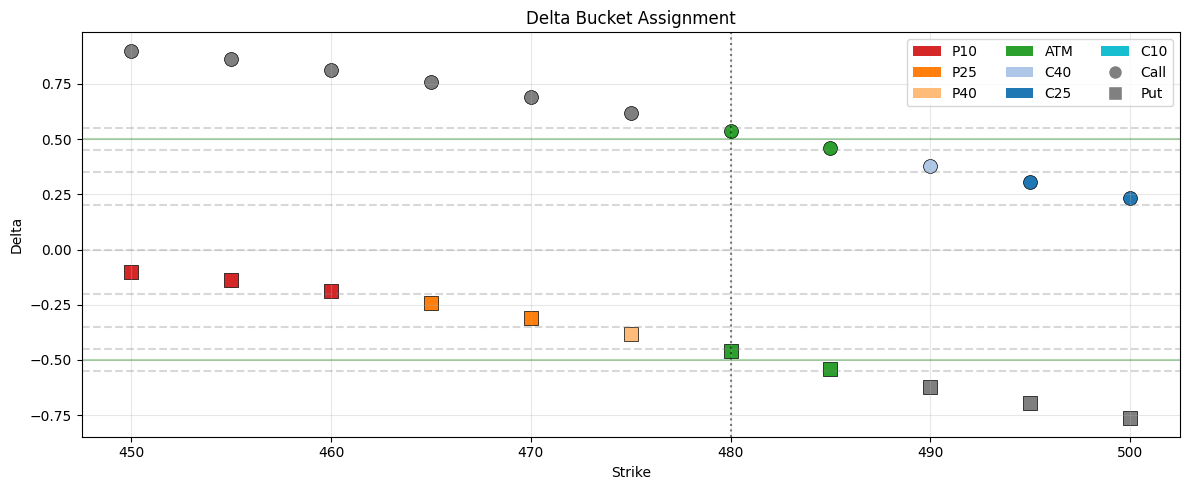

In [10]:
# Visualize bucket assignments
fig, ax = plt.subplots(figsize=(12, 5))

colors = {
    'P10': '#d62728', 'P25': '#ff7f0e', 'P40': '#ffbb78',
    'ATM': '#2ca02c',
    'C40': '#aec7e8', 'C25': '#1f77b4', 'C10': '#17becf',
    None: '#7f7f7f'
}

for _, row in all_options.iterrows():
    marker = 'o' if row['Right'] == 'C' else 's'
    color = colors.get(row['Bucket'], '#7f7f7f')
    ax.scatter(row['Strike'], row['Delta'], c=color, marker=marker, s=100, edgecolors='black', linewidth=0.5)

# Add bucket boundaries
for y in [-0.55, -0.45, -0.35, -0.20, 0.0, 0.20, 0.35, 0.45, 0.55]:
    ax.axhline(y, color='gray', linestyle='--', alpha=0.3)

ax.axvline(S, color='black', linestyle=':', alpha=0.5, label=f'Spot (${S})')
ax.axhline(0.5, color='green', linestyle='-', alpha=0.3)
ax.axhline(-0.5, color='green', linestyle='-', alpha=0.3)

# Legend
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor=colors['P10'], label='P10'),
    Patch(facecolor=colors['P25'], label='P25'),
    Patch(facecolor=colors['P40'], label='P40'),
    Patch(facecolor=colors['ATM'], label='ATM'),
    Patch(facecolor=colors['C40'], label='C40'),
    Patch(facecolor=colors['C25'], label='C25'),
    Patch(facecolor=colors['C10'], label='C10'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='Call'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=10, label='Put'),
]
ax.legend(handles=legend_elements, loc='upper right', ncol=3)

ax.set_xlabel('Strike')
ax.set_ylabel('Delta')
ax.set_title('Delta Bucket Assignment')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Quality Filters Demo

The `QualityFilter` class computes bitfield-encoded quality flags for each option quote.

In [11]:
# Configure quality filter
quality_config = QualityConfig(
    allow_crossed_quotes=False,
    max_spread_pct=0.50,      # 50% spread threshold
    min_volume=10,            # Minimum volume
    min_open_interest=100,    # Minimum OI
)

quality_filter = QualityFilter(quality_config)

print("Quality Filter Configuration:")
print(f"  Allow crossed quotes: {quality_config.allow_crossed_quotes}")
print(f"  Max spread %: {quality_config.max_spread_pct*100:.0f}%")
print(f"  Min volume: {quality_config.min_volume}")
print(f"  Min open interest: {quality_config.min_open_interest}")

print("\nFlag Bit Values:")
print(f"  FLAG_CROSSED:     {QualityFilter.FLAG_CROSSED:05b} ({QualityFilter.FLAG_CROSSED})")
print(f"  FLAG_STALE:       {QualityFilter.FLAG_STALE:05b} ({QualityFilter.FLAG_STALE})")
print(f"  FLAG_WIDE_SPREAD: {QualityFilter.FLAG_WIDE_SPREAD:05b} ({QualityFilter.FLAG_WIDE_SPREAD})")
print(f"  FLAG_LOW_VOLUME:  {QualityFilter.FLAG_LOW_VOLUME:05b} ({QualityFilter.FLAG_LOW_VOLUME})")
print(f"  FLAG_LOW_OI:      {QualityFilter.FLAG_LOW_OI:05b} ({QualityFilter.FLAG_LOW_OI})")

Quality Filter Configuration:
  Allow crossed quotes: False
  Max spread %: 50%
  Min volume: 10
  Min open interest: 100

Flag Bit Values:
  FLAG_CROSSED:     00001 (1)
  FLAG_STALE:       00010 (2)
  FLAG_WIDE_SPREAD: 00100 (4)
  FLAG_LOW_VOLUME:  01000 (8)
  FLAG_LOW_OI:      10000 (16)


In [12]:
# Create sample quotes with various quality issues
sample_quotes = pd.DataFrame({
    'option_symbol': ['GOOD1', 'CROSSED', 'WIDE', 'LOWVOL', 'LOWOI', 'MULTI'],
    'bid': [5.00, 5.50, 5.00, 5.00, 5.00, 5.50],   # CROSSED: bid > ask
    'ask': [5.10, 5.00, 10.00, 5.10, 5.10, 5.00],  # WIDE: huge spread
    'volume': [100, 100, 100, 5, 100, 5],          # LOWVOL: vol < 10
    'open_interest': [500, 500, 500, 500, 50, 50], # LOWOI: OI < 100
})

# Add mid price and spread for quality filter
sample_quotes['mid_price'] = (sample_quotes['bid'] + sample_quotes['ask']) / 2
sample_quotes['spread_pct'] = (sample_quotes['ask'] - sample_quotes['bid']) / sample_quotes['mid_price']

# Compute quality flags
sample_quotes['flags'] = quality_filter.compute_flags(sample_quotes)
sample_quotes['is_good'] = quality_filter.is_good_quality(sample_quotes['flags'])
sample_quotes['flag_description'] = sample_quotes['flags'].apply(quality_filter.describe_flags)

print("Sample Quotes with Quality Flags:")
display_cols = ['option_symbol', 'bid', 'ask', 'spread_pct', 'volume', 'open_interest', 'flags', 'is_good', 'flag_description']
print(sample_quotes[display_cols].to_string(index=False))

Sample Quotes with Quality Flags:
option_symbol    bid     ask  spread_pct  volume  open_interest  flags  is_good              flag_description
        GOOD1 5.0000  5.1000      0.0198     100            500      0     True                            []
      CROSSED 5.5000  5.0000     -0.0952     100            500      1    False                     [CROSSED]
         WIDE 5.0000 10.0000      0.6667     100            500      4    False                 [WIDE_SPREAD]
       LOWVOL 5.0000  5.1000      0.0198       5            500      8    False                  [LOW_VOLUME]
        LOWOI 5.0000  5.1000      0.0198     100             50     16    False                      [LOW_OI]
        MULTI 5.5000  5.0000     -0.0952       5             50     25    False [CROSSED, LOW_VOLUME, LOW_OI]


In [13]:
# Demonstrate flag checking
print("\nFlag Checking Examples:")
for _, row in sample_quotes.iterrows():
    flags = row['flags']
    symbol = row['option_symbol']
    print(f"\n{symbol} (flags={flags:05b}):")
    print(f"  Has CROSSED:     {quality_filter.has_flag(pd.Series([flags]), QualityFilter.FLAG_CROSSED).iloc[0]}")
    print(f"  Has WIDE_SPREAD: {quality_filter.has_flag(pd.Series([flags]), QualityFilter.FLAG_WIDE_SPREAD).iloc[0]}")
    print(f"  Has LOW_VOLUME:  {quality_filter.has_flag(pd.Series([flags]), QualityFilter.FLAG_LOW_VOLUME).iloc[0]}")
    print(f"  Has LOW_OI:      {quality_filter.has_flag(pd.Series([flags]), QualityFilter.FLAG_LOW_OI).iloc[0]}")


Flag Checking Examples:

GOOD1 (flags=00000):
  Has CROSSED:     False
  Has WIDE_SPREAD: False
  Has LOW_VOLUME:  False
  Has LOW_OI:      False

CROSSED (flags=00001):
  Has CROSSED:     True
  Has WIDE_SPREAD: False
  Has LOW_VOLUME:  False
  Has LOW_OI:      False

WIDE (flags=00100):
  Has CROSSED:     False
  Has WIDE_SPREAD: True
  Has LOW_VOLUME:  False
  Has LOW_OI:      False

LOWVOL (flags=01000):
  Has CROSSED:     False
  Has WIDE_SPREAD: False
  Has LOW_VOLUME:  True
  Has LOW_OI:      False

LOWOI (flags=10000):
  Has CROSSED:     False
  Has WIDE_SPREAD: False
  Has LOW_VOLUME:  False
  Has LOW_OI:      True

MULTI (flags=11001):
  Has CROSSED:     True
  Has WIDE_SPREAD: False
  Has LOW_VOLUME:  True
  Has LOW_OI:      True


## 5. Full Surface Construction Demo

Now let's put it all together to build a complete IV surface.

In [ ]:
# Create a realistic option chain with multiple expirations
def create_option_chain(underlying_price, expirations_days, strikes_range):
    """Create a synthetic option chain."""
    rows = []
    
    for dte in expirations_days:
        T = dte / 365
        
        for strike in strikes_range:
            moneyness = strike / underlying_price
            
            # IV with skew and term structure
            base_iv = 0.18
            skew = 0.12 * (1 - moneyness)  # Put skew
            term = 0.02 * np.sqrt(T)        # Term structure
            iv = base_iv + skew + term
            
            # Generate prices
            call_price = bs_call_price(underlying_price, strike, T, r, q, iv)
            put_price = call_price - underlying_price + strike * np.exp(-r * T)  # Put-call parity
            
            # Add realistic bid-ask spread
            spread_pct = 0.02 + 0.05 * abs(moneyness - 1)  # Wider spreads for OTM
            
            for right, price in [('C', call_price), ('P', put_price)]:
                if price > 0.05:  # Skip near-zero prices
                    bid = price * (1 - spread_pct/2)
                    ask = price * (1 + spread_pct/2)
                    
                    rows.append({
                        'strike': strike,
                        'right': right,
                        'dte': dte,
                        'true_iv': iv,
                        'bid': round(bid, 2),
                        'ask': round(ask, 2),
                        'volume': np.random.randint(50, 500),
                        'open_interest': np.random.randint(200, 2000),
                    })
    
    return pd.DataFrame(rows)

# Generate chain
S = 480.0
expirations = list(SurfaceConstants.TENOR_DAYS_DEFAULT)[:5]  # Use standard tenors (first 5)
strikes_range = np.arange(440, 520, 5, dtype=float)

chain = create_option_chain(S, expirations, strikes_range)
print(f"Generated {len(chain)} options across {len(expirations)} expirations")
print(chain.head(10))

In [15]:
# Process the full chain through our surface engine

# 1. Compute mid price and spread
chain['mid_price'] = (chain['bid'] + chain['ask']) / 2
chain['spread_pct'] = (chain['ask'] - chain['bid']) / chain['mid_price']

# 2. Compute time to expiry
chain['tte_years'] = chain['dte'] / 365

# 3. Invert IV
chain['iv_mid'] = iv_solver.solve_iv_vectorized(
    prices=pd.Series(chain['mid_price'].values),
    S=pd.Series([S] * len(chain)),
    K=pd.Series(chain['strike'].values),
    T=pd.Series(chain['tte_years'].values),
    r=pd.Series([r] * len(chain)),
    q=q,
    right=pd.Series(chain['right'].values)
)

# 4. Compute Greeks
greeks = greeks_calc.compute_greeks_vectorized(
    S=pd.Series([S] * len(chain)),
    K=pd.Series(chain['strike'].values),
    T=pd.Series(chain['tte_years'].values),
    r=r,
    q=q,
    sigma=chain['iv_mid'],
    right=pd.Series(chain['right'].values)
)
chain = pd.concat([chain.reset_index(drop=True), greeks.reset_index(drop=True)], axis=1)

# 5. Assign buckets
chain['delta_bucket'] = bucket_assigner.assign(chain['delta'])

# 6. Compute quality flags
chain['flags'] = quality_filter.compute_flags(chain)
chain['is_good'] = quality_filter.is_good_quality(chain['flags'])

print(f"\nProcessed {len(chain)} options")
print(f"Valid IV inversions: {chain['iv_mid'].notna().sum()}")
print(f"Good quality quotes: {chain['is_good'].sum()}")
print(f"\nBucket distribution:")
print(chain['delta_bucket'].value_counts().sort_index())


Processed 155 options
Valid IV inversions: 124
Good quality quotes: 155

Bucket distribution:
delta_bucket
ATM    14
C25    11
C40     7
P25    12
P40     7
Name: count, dtype: int64


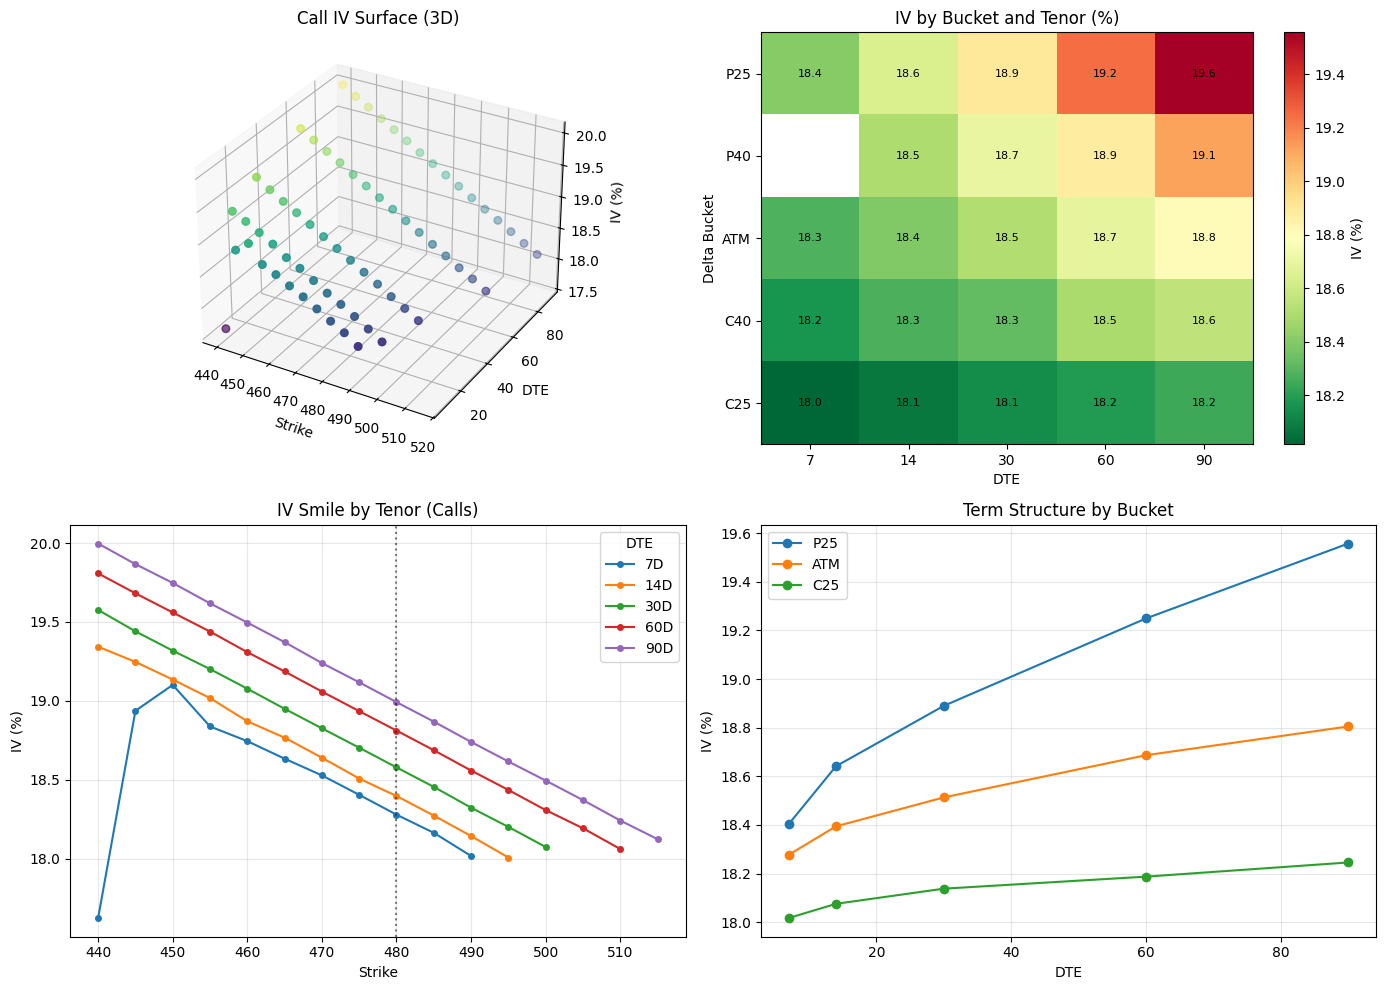

In [16]:
# Visualize the IV surface
fig = plt.figure(figsize=(14, 10))

# 3D Surface plot
ax1 = fig.add_subplot(221, projection='3d')

# Filter to good quality calls only for cleaner visualization
calls = chain[(chain['right'] == 'C') & (chain['is_good']) & (chain['iv_mid'].notna())]

ax1.scatter(calls['strike'], calls['dte'], calls['iv_mid'] * 100, 
            c=calls['iv_mid'] * 100, cmap='viridis', s=30)
ax1.set_xlabel('Strike')
ax1.set_ylabel('DTE')
ax1.set_zlabel('IV (%)')
ax1.set_title('Call IV Surface (3D)')

# Heatmap by bucket and tenor
ax2 = fig.add_subplot(222)
pivot = chain[chain['is_good']].pivot_table(
    values='iv_mid', 
    index='delta_bucket', 
    columns='dte', 
    aggfunc='mean'
) * 100

# Reorder buckets
bucket_order = ['P10', 'P25', 'P40', 'ATM', 'C40', 'C25', 'C10']
pivot = pivot.reindex([b for b in bucket_order if b in pivot.index])

im = ax2.imshow(pivot.values, aspect='auto', cmap='RdYlGn_r')
ax2.set_xticks(range(len(pivot.columns)))
ax2.set_xticklabels(pivot.columns)
ax2.set_yticks(range(len(pivot.index)))
ax2.set_yticklabels(pivot.index)
ax2.set_xlabel('DTE')
ax2.set_ylabel('Delta Bucket')
ax2.set_title('IV by Bucket and Tenor (%)')
plt.colorbar(im, ax=ax2, label='IV (%)')

# Add IV values to heatmap
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.iloc[i, j]
        if not np.isnan(val):
            ax2.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=8)

# IV Smile by tenor
ax3 = fig.add_subplot(223)
for dte in sorted(chain['dte'].unique()):
    subset = chain[(chain['dte'] == dte) & (chain['right'] == 'C') & (chain['is_good'])]
    ax3.plot(subset['strike'], subset['iv_mid'] * 100, 'o-', label=f'{dte}D', markersize=4)

ax3.axvline(S, color='black', linestyle=':', alpha=0.5)
ax3.set_xlabel('Strike')
ax3.set_ylabel('IV (%)')
ax3.set_title('IV Smile by Tenor (Calls)')
ax3.legend(title='DTE')
ax3.grid(True, alpha=0.3)

# Term structure by bucket
ax4 = fig.add_subplot(224)
for bucket in ['P25', 'ATM', 'C25']:
    subset = chain[(chain['delta_bucket'] == bucket) & (chain['is_good'])]
    avg_iv = subset.groupby('dte')['iv_mid'].mean() * 100
    ax4.plot(avg_iv.index, avg_iv.values, 'o-', label=bucket, markersize=6)

ax4.set_xlabel('DTE')
ax4.set_ylabel('IV (%)')
ax4.set_title('Term Structure by Bucket')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# Summary statistics
print("=" * 60)
print("SURFACE ENGINE SUMMARY")
print("=" * 60)

print(f"\nUnderlying: ${S:.2f}")
print(f"Risk-free rate: {r*100:.2f}%")
print(f"Total options: {len(chain)}")
print(f"Successful IV inversions: {chain['iv_mid'].notna().sum()} ({chain['iv_mid'].notna().mean()*100:.1f}%)")
print(f"Good quality quotes: {chain['is_good'].sum()} ({chain['is_good'].mean()*100:.1f}%)")

print(f"\nIV Statistics (good quotes only):")
good_chain = chain[chain['is_good']]
print(f"  Min IV: {good_chain['iv_mid'].min()*100:.1f}%")
print(f"  Max IV: {good_chain['iv_mid'].max()*100:.1f}%")
print(f"  Mean IV: {good_chain['iv_mid'].mean()*100:.1f}%")
print(f"  ATM IV (30D): {good_chain[(good_chain['delta_bucket'] == 'ATM') & (good_chain['dte'] == 30)]['iv_mid'].mean()*100:.1f}%")

print(f"\nBucket Coverage:")
for bucket in bucket_order:
    count = (good_chain['delta_bucket'] == bucket).sum()
    tenors = good_chain[good_chain['delta_bucket'] == bucket]['dte'].nunique()
    print(f"  {bucket}: {count} options across {tenors} tenors")

print("\n" + "=" * 60)
print("Surface Engine Demo Complete!")
print("=" * 60)

SURFACE ENGINE SUMMARY

Underlying: $480.00
Risk-free rate: 4.50%
Total options: 155
Successful IV inversions: 124 (80.0%)
Good quality quotes: 155 (100.0%)

IV Statistics (good quotes only):
  Min IV: 16.7%
  Max IV: 20.0%
  Mean IV: 18.6%
  ATM IV (30D): 18.5%

Bucket Coverage:
  P10: 0 options across 0 tenors
  P25: 12 options across 5 tenors
  P40: 7 options across 4 tenors
  ATM: 14 options across 5 tenors
  C40: 7 options across 5 tenors
  C25: 11 options across 5 tenors
  C10: 0 options across 0 tenors

Surface Engine Demo Complete!
